# E-Commerce Hybrid Recommendation System

**Pipeline:**
1. Load the raw event data
2. Rebuild the content-based side (product catalog + TF-IDF)
3. Rebuild the collaborative side (filtered user-item matrix + item co-purchase similarity)
4. Combine both into a single weighted **hybrid score**
5. Write `hybrid_recommend()` and demo it
6. Compare content-only vs collaborative-only vs hybrid results side by side
7. Visualize how the blend weight `alpha` changes the recommendations


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

Load the Dataset

In [3]:
df = pd.read_csv('kz.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (434799, 8)


,event_time,order_id,product_id,category_id,category_code,brand,price,user_id
0,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2268105426648170900,electronics.tablet,samsung,162.01,1515915625441993984
1,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2268105426648170900,electronics.tablet,samsung,162.01,1515915625441993984
2,2020-04-24 14:37:43 UTC,2294444024058086220,2273948319057183658,2268105430162997728,electronics.audio.headphone,huawei,77.52,1515915625447879434
3,2020-04-24 14:37:43 UTC,2294444024058086220,2273948319057183658,2268105430162997728,electronics.audio.headphone,huawei,77.52,1515915625447879434
4,2020-04-26 08:45:57 UTC,2295716521449619559,1515966223509261697,2268105442636858090,furniture.kitchen.table,maestro,39.33,1515915625450382722


Content-Based Side

In [4]:
products = (
    df.groupby('product_id')
      .agg(
          category_id=('category_id', 'first'),
          category_code=('category_code', 'first'),
          brand=('brand', lambda s: s.mode().iat[0] if not s.mode().empty else 'unknown'),
          price=('price', 'mean'),
          n_purchases=('product_id', 'size'),
      )
      .reset_index()
)
products['brand'] = products['brand'].fillna('unknown').str.lower().str.strip()
products['price'] = products['price'].round(2)

def split_category(code):
    parts = str(code).split('.')
    parts += [parts[-1]] * (3 - len(parts))
    return parts[0], parts[1], parts[2]

products[['category_l1', 'category_l2', 'category_l3']] = products['category_code'].apply(
    lambda c: pd.Series(split_category(c))
)
products['price_tier'] = pd.qcut(
    products['price'], q=4, labels=['budget', 'mid', 'premium', 'luxury'], duplicates='drop'
)
products['content'] = (
    products['category_l1'] + ' ' +
    products['category_l2'] + ' ' +
    products['category_l3'] + ' ' +
    (products['brand'] + ' ') * 2 +
    products['price_tier'].astype(str)
)

print(f"Product catalog shape: {products.shape}")
products.head()

Product catalog shape: (12325, 11)


,product_id,category_id,category_code,brand,price,n_purchases,category_l1,category_l2,category_l3,price_tier,content
0,1515966223509088493,2268105428166508982,electronics.smartphone,apple,740.72,417,electronics,smartphone,smartphone,luxury,electronics smartphone smartphone apple apple ...
1,1515966223509088496,2268105458457772096,apparel.glove,xbox,266.18,161,apparel,glove,glove,premium,apparel glove glove xbox xbox premium
2,1515966223509088497,2268105428166508982,electronics.smartphone,samsung,1215.25,424,electronics,smartphone,smartphone,luxury,electronics smartphone smartphone samsung sams...
3,1515966223509088498,2268105428166508982,electronics.smartphone,samsung,115.72,479,electronics,smartphone,smartphone,premium,electronics smartphone smartphone samsung sams...
4,1515966223509088499,2268105407220155366,computers.notebook,lenovo,601.83,78,computers,notebook,notebook,luxury,computers notebook notebook lenovo lenovo luxury


In [5]:
tfidf = TfidfVectorizer(token_pattern=r"[a-zA-Z0-9]+")
tfidf_matrix = tfidf.fit_transform(products['content'])
catalog_idx = pd.Series(products.index, index=products['product_id'])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}  (products x vocabulary)")

TF-IDF matrix shape: (12325, 742)  (products x vocabulary)


Collaborative Side

In [6]:
user_counts = df['user_id'].value_counts()
prod_counts = df['product_id'].value_counts()

active_users = user_counts[user_counts >= 3].index
active_products = prod_counts[prod_counts >= 5].index
interactions = df[
    df['user_id'].isin(active_users) & df['product_id'].isin(active_products)
].copy()

cf_prods = pd.Index(sorted(interactions['product_id'].unique()), name='product_id')
cf_users = pd.Index(sorted(interactions['user_id'].unique()), name='user_id')
cf_prod_idx = pd.Series(np.arange(len(cf_prods)), index=cf_prods)
cf_user_idx = pd.Series(np.arange(len(cf_users)), index=cf_users)

rows = interactions['product_id'].map(cf_prod_idx).values
cols = interactions['user_id'].map(cf_user_idx).values
data = np.ones(len(interactions), dtype=np.float32)
item_user = csr_matrix((data, (rows, cols)), shape=(len(cf_prods), len(cf_users)))

print(f"item-user matrix shape: {item_user.shape}")
print(f"Products with collaborative signal: {len(cf_prods):,} of {len(products):,} in the full catalog")

item-user matrix shape: (6974, 44324)
Products with collaborative signal: 6,974 of 12,325 in the full catalog


Combine

In [7]:
def hybrid_recommend(product_id, top_n=10, alpha=0.5):
    if product_id not in catalog_idx.index:
        raise ValueError(f"product_id {product_id} not found in the catalog")

    # Content-based similarity across the whole catalog
    c_idx = catalog_idx[product_id]
    content_sim = cosine_similarity(tfidf_matrix[c_idx], tfidf_matrix).flatten()
    content_sim = pd.Series(content_sim, index=products['product_id'])

    # Collaborative similarity, only defined for products with enough purchase history
    if product_id in cf_prod_idx.index:
        cf_idx = cf_prod_idx[product_id]
        collab_sim = cosine_similarity(item_user[cf_idx], item_user).flatten()
        collab_sim = pd.Series(collab_sim, index=cf_prods)
    else:
        collab_sim = pd.Series(dtype=float)
    collab_sim = collab_sim.reindex(content_sim.index, fill_value=0.0)

    hybrid_score = alpha * content_sim + (1 - alpha) * collab_sim
    hybrid_score = hybrid_score.drop(index=product_id)  # exclude the query product itself

    top = hybrid_score.sort_values(ascending=False).head(top_n)
    result = products.set_index('product_id').loc[top.index, ['category_code', 'brand', 'price']].copy()
    result['hybrid_score'] = top.values
    return result.reset_index()

Demo: Hybrid Recommendations

In [8]:
# Pick a product that has both content features and strong purchase history
demo_product_id = prod_counts.loc[cf_prods].sort_values(ascending=False).index[0]

query_product = products.set_index('product_id').loc[[demo_product_id], ['category_code', 'brand', 'price']].reset_index()
print("Query product:")
display(query_product)

print("\nTop 10 hybrid recommendations (alpha=0.5):")
hybrid_recommend(demo_product_id, top_n=10, alpha=0.5)

Query product:


,product_id,category_code,brand,price
0,1515966223517846928,electronics.smartphone,samsung,173.59



Top 10 hybrid recommendations (alpha=0.5):


,product_id,category_code,brand,price,hybrid_score
0,1515966223517846980,electronics.smartphone,samsung,173.59,0.582589
1,1515966223517846906,electronics.smartphone,samsung,173.59,0.557485
2,1515966223510174551,electronics.smartphone,samsung,208.31,0.553404
3,1515966223509106786,electronics.smartphone,samsung,138.87,0.550540
4,1515966223522710798,electronics.smartphone,samsung,138.87,0.549455
5,1515966223509088521,electronics.smartphone,samsung,115.72,0.545752
6,1515966223522710797,electronics.smartphone,samsung,138.87,0.533041
7,1515966223509089067,electronics.smartphone,samsung,138.87,0.532561
8,1515966223509090011,electronics.smartphone,samsung,138.87,0.525108
9,1515966223509089514,electronics.smartphone,samsung,254.61,0.524202


Comparing three function

In [9]:
content_only = hybrid_recommend(demo_product_id, top_n=5, alpha=1.0).rename(columns={'hybrid_score': 'content_score'})
collab_only = hybrid_recommend(demo_product_id, top_n=5, alpha=0.0).rename(columns={'hybrid_score': 'collab_score'})
blended = hybrid_recommend(demo_product_id, top_n=5, alpha=0.5)

print("Content-based only (alpha=1.0):")
display(content_only)

print("\nCollaborative only (alpha=0.0):")
display(collab_only)

print("\nHybrid blend (alpha=0.5):")
blended

Content-based only (alpha=1.0):


,product_id,category_code,brand,price,content_score
0,1515966223509104145,electronics.smartphone,samsung,231.23,1.0
1,1515966223509088552,electronics.smartphone,samsung,196.27,1.0
2,1515966223509104163,electronics.smartphone,samsung,115.49,1.0
3,1515966223509104162,electronics.smartphone,samsung,161.78,1.0
4,1515966223509089982,electronics.smartphone,samsung,208.08,1.0



Collaborative only (alpha=0.0):


,product_id,category_code,brand,price,collab_score
0,1515966223517846980,electronics.smartphone,samsung,173.59,0.165178
1,1515966223517846906,electronics.smartphone,samsung,173.59,0.114970
2,1515966223510174551,electronics.smartphone,samsung,208.31,0.106807
3,1515966223509106786,electronics.smartphone,samsung,138.87,0.101079
4,1515966223522710798,electronics.smartphone,samsung,138.87,0.098910



Hybrid blend (alpha=0.5):


,product_id,category_code,brand,price,hybrid_score
0,1515966223517846980,electronics.smartphone,samsung,173.59,0.582589
1,1515966223517846906,electronics.smartphone,samsung,173.59,0.557485
2,1515966223510174551,electronics.smartphone,samsung,208.31,0.553404
3,1515966223509106786,electronics.smartphone,samsung,138.87,0.550540
4,1515966223522710798,electronics.smartphone,samsung,138.87,0.549455


Visualize How Alpha Changes the Recommendations

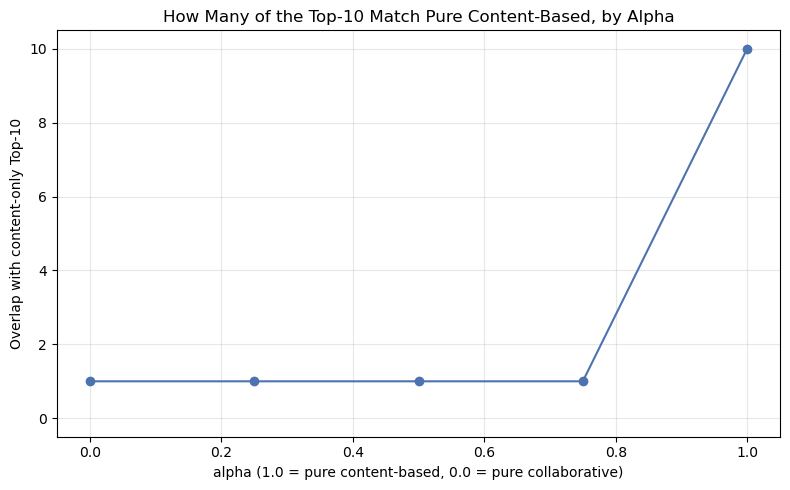

In [10]:
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
overlap_with_content_only = []

pure_content_ids = set(hybrid_recommend(demo_product_id, top_n=10, alpha=1.0)['product_id'])

for a in alphas:
    rec_ids = set(hybrid_recommend(demo_product_id, top_n=10, alpha=a)['product_id'])
    overlap_with_content_only.append(len(rec_ids & pure_content_ids))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alphas, overlap_with_content_only, marker='o', color='#4C72B0')
ax.set_title('How Many of the Top-10 Match Pure Content-Based, by Alpha')
ax.set_xlabel('alpha (1.0 = pure content-based, 0.0 = pure collaborative)')
ax.set_ylabel('Overlap with content-only Top-10')
ax.set_ylim(-0.5, 10.5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()